In [1]:
import os
import pandas as pd
import json
import numpy as np


In [2]:
few_shot_path = "../results/roberta-base/brexit/Hate/"
dataset = 'brexit'
n_anns = 6
mtl_budget_map = {3: "0.5", 4: "0.66", 5: "0.83", 6: "1"}
test_file_name = 'test_result.json'
# strategy= 'mv'

f1_list = []
f1_list_baselines = []

for root, subdirs, files in os.walk(few_shot_path):
    # print(root)
    
    if "few_shot" in root:
            for file in files:
                if file == f'{test_file_name}':
                    with open(os.path.join(root, file), 'r') as f:
                        data = json.load(f)
                        # print(root)
                        annotator = root.split('/')[-2]
                        k_shot = root.split('/')[-3]
                        sampling = root.split('/')[-5]
                        mtl = root.split('/')[-1]
                        n_mtl = len(mtl.split('_')[1].split(","))
                        seed = root.split('/')[-8]
                        # print(annotator)
                        # Loop through each annotator in the file
                        # for i, annotator in enumerate(data['task_name']):
                        #     # Append f1 and auc to respective lists
                        f1_list.append(
                            {'Annotator': annotator, 'F1': data['f1'], 'AUC': data['auc'], 'seed': seed,
                            'k-shot': k_shot, 'n_mtl': n_mtl, 'mtl': mtl, 'sampling': sampling})
    elif f"mtl" in root:
        for file in files:
            if file == f"{test_file_name}":
                with open(os.path.join(root, file), 'r') as f:
                    data = json.load(f)
                    # print(root)
                    budget = root.split('/')[-3].split('_')[-1]
                    seed = root.split('/')[-4]
                    n_mtls = root.split('/')[-2].split('_')[-1]
                    annotator = root.split('/')[-1]
                    # print(n_mtls)
                    f1_list_baselines.append(
                        {'budget': budget, 'F1': data['avg_val_f1'], 'AUC': data['avg_val_auc'],
                        'n_mtl': n_mtls , 'seed': seed, 'sampling' : 'mtl', 'mtl': annotator})
# Create dataframes for f1 and auc
f1_df = pd.DataFrame(f1_list)

f1_baseline_df = pd.DataFrame(f1_list_baselines)
f1_baseline_df['k-shot'] = "0"

# Group by annotator and calculate the average
f1_df = f1_df.groupby(
    ['n_mtl', 'k-shot', 'seed', 'sampling']).agg({'F1': 'mean', 'AUC': 'mean'}).reset_index()

f1_df['budget'] = f1_df['n_mtl'].map(mtl_budget_map)

f1_baseline_df = f1_baseline_df.groupby(['n_mtl', 'k-shot', 'seed', 'sampling', 'budget']).agg({'F1': 'mean', 'AUC': 'mean'}).reset_index()
# decimal_places = 3

result_df = pd.concat([f1_df, f1_baseline_df], ignore_index=True)
result_df = result_df[result_df['sampling'].isin(['mtl', 'strategy_random'])]


baseline = result_df[(result_df['n_mtl'] == "6")]
unagg_baseline_br = baseline.copy()
mtl_fs = result_df[(result_df['budget'] != '1.0') & (result_df['n_mtl'] != "6")]

baseline = baseline.groupby(['k-shot','budget']).agg({'F1': ['mean', 'std']}).reset_index()
baseline['f1_mean'] = baseline['F1']['mean'].round(3).astype(str) + "_{(" + baseline['F1']['std'].round(3).astype(str) + ")}"
baseline = baseline.pivot(index='k-shot',columns=['budget'], values='f1_mean').sort_index().reset_index()
baseline

def get_weighted_avg_with_mtl(mtl_f1, row):
    return (mtl_f1[row['budget']] * float(row['budget']) + row['F1'] * (1-float(row['budget']))) 

def get_mtl_f1(mtl_f1, row):
    return mtl_f1[row['budget']]

def get_avg_with_mtl(mtl_f1, row):
    return (mtl_f1[row['budget']] + row['F1'])/2
seeds = mtl_fs['seed'].unique()
dfs = []
mtl_dfs = []
for seed in seeds:
    df = mtl_fs[mtl_fs['seed'] == seed]
    mtl_f1_df = df[df['sampling'] == 'mtl'][['budget', 'F1']].set_index('budget')
    mtl_f1 = mtl_f1_df.to_dict()['F1']
    df['avg_f1'] = df.apply(lambda row : get_mtl_f1(mtl_f1, row), axis=1)
    mtl_dfs.append(mtl_f1_df)
    # print(mtl_f1)
    # print(df)
    dfs.append(df)
  
concat_df = pd.concat(dfs, ignore_index=True)
unagg_df_br = concat_df.copy()
concat_df = concat_df[concat_df['sampling'] =='strategy_random'].groupby(['n_mtl', 'k-shot', 'sampling', 'budget']).agg({'avg_f1': ['mean', 'std']}).reset_index()
concat_df['f1_mean'] = concat_df['avg_f1']['mean'].round(3).astype(str) + "_{(" + concat_df['avg_f1']['std'].round(3).astype(str) + ")}"
concat_df = concat_df.pivot(index='k-shot',columns=['budget'], values='f1_mean').sort_index().reset_index()
# concat_df 

concat_df = pd.concat([concat_df, baseline], ignore_index=True)
brexit_df = concat_df.sort_values(by=['k-shot']).reset_index(drop=True)
brexit_df

/tmp/ipykernel_3222825/4006540461.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_f1'] = df.apply(lambda row : get_mtl_f1(mtl_f1, row), axis=1)
/tmp/ipykernel_3222825/4006540461.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_f1'] = df.apply(lambda row : get_mtl_f1(mtl_f1, row), axis=1)
/tmp/ipykernel_3222825/4006540461.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

budget,k-shot,0.5,0.66,0.83,1.0
0,0,0.417_{(0.049)},0.449_{(0.027)},0.418_{(0.018)},0.431_{(0.014)}
1,128,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN
2,16,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN
3,32,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN
4,64,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN


### MFRC 

In [3]:
few_shot_path = "../results/roberta-base/mfrc/Moral/"
dataset = 'mfrc'
n_anns = "24"
test_file_name = 'test_result.json'
mtl_budget_map ={6: "0.25", 12: "0.5", 18: "0.75", 24:"1"}
# f1_list = []
# f1_list_baselines = []
# strategy = 'mv'


# few_shot_path = "../results/roberta-base/brexit/Hate/"
# dataset = 'brexit'
# n_anns = 6
# mtl_budget_map = {3: "0.5", 4: "0.66", 5: "0.83", 6: "1"}
# test_file_name = 'test_result.json'
# # strategy= 'mv'

f1_list = []
f1_list_baselines = []

for root, subdirs, files in os.walk(few_shot_path):
    # print(root)
    
    if "few_shot" in root:
            for file in files:
                if file == f'{test_file_name}':
                    with open(os.path.join(root, file), 'r') as f:
                        data = json.load(f)
                        # print(root)
                        annotator = root.split('/')[-2]
                        k_shot = root.split('/')[-3]
                        sampling = root.split('/')[-5]
                        mtl = root.split('/')[-1]
                        n_mtl = len(mtl.split('_')[1].split(","))
                        seed = root.split('/')[-8]
                        # print(annotator)
                        # Loop through each annotator in the file
                        # for i, annotator in enumerate(data['task_name']):
                        #     # Append f1 and auc to respective lists
                        f1_list.append(
                            {'Annotator': annotator, 'F1': data['f1'], 'AUC': data['auc'], 'seed': seed,
                            'k-shot': k_shot, 'n_mtl': n_mtl, 'mtl': mtl, 'sampling': sampling})
    elif f"mtl" in root:
        for file in files:
            if file == f"{test_file_name}":
                with open(os.path.join(root, file), 'r') as f:
                    data = json.load(f)
                    # print(root)
                    budget = root.split('/')[-3].split('_')[-1]
                    seed = root.split('/')[-4]
                    n_mtls = root.split('/')[-2].split('_')[-1]
                    annotator = root.split('/')[-1]
                    # print(n_mtls)
                    f1_list_baselines.append(
                        {'budget': budget, 'F1': data['avg_val_f1'], 'AUC': data['avg_val_auc'],
                        'n_mtl': n_mtls , 'seed': seed, 'sampling' : 'mtl', 'mtl': annotator})
# Create dataframes for f1 and auc
f1_df = pd.DataFrame(f1_list)

f1_baseline_df = pd.DataFrame(f1_list_baselines)
f1_baseline_df['k-shot'] = "0"

# Group by annotator and calculate the average
f1_df = f1_df.groupby(
    ['n_mtl', 'k-shot', 'seed', 'sampling']).agg({'F1': 'mean', 'AUC': 'mean'}).reset_index()

f1_df['budget'] = f1_df['n_mtl'].map(mtl_budget_map)

f1_baseline_df = f1_baseline_df.groupby(['n_mtl', 'k-shot', 'seed', 'sampling', 'budget']).agg({'F1': 'mean', 'AUC': 'mean'}).reset_index()
# decimal_places = 3

result_df = pd.concat([f1_df, f1_baseline_df], ignore_index=True)
result_df = result_df[result_df['sampling'].isin(['mtl', 'strategy_random'])]


baseline = result_df[(result_df['n_mtl'] == n_anns)]
unagg_baseline_mf = baseline.copy()
mtl_fs = result_df[(result_df['budget'] != '1.0') & (result_df['n_mtl'] != n_anns)]

baseline = baseline.groupby(['k-shot','budget']).agg({'F1': ['mean', 'std']}).reset_index()
baseline['f1_mean'] = baseline['F1']['mean'].round(3).astype(str) + "_{(" + baseline['F1']['std'].round(3).astype(str) + ")}"
baseline = baseline.pivot(index='k-shot',columns=['budget'], values='f1_mean').sort_index().reset_index()

# def get_avg_with_mtl(mtl_f1, row):
#     return (mtl_f1[row['budget']] * row['budget'] + row['F1'] * (1-row['budget']))


seeds = mtl_fs['seed'].unique()
dfs = []
mtl_dfs = []
for seed in seeds:
    df = mtl_fs[mtl_fs['seed'] == seed]
    mtl_f1_df = df[df['sampling'] == 'mtl'][['budget', 'F1']].set_index('budget')
    mtl_f1 = mtl_f1_df.to_dict()['F1']
    df['avg_f1'] = df.apply(lambda row : get_mtl_f1(mtl_f1, row), axis=1)
    mtl_dfs.append(mtl_f1_df)
    # print(mtl_f1)
    # print(df)
    dfs.append(df)
  
concat_df = pd.concat(dfs, ignore_index=True)
unagg_df_mf = concat_df.copy()
concat_df = concat_df[concat_df['sampling'] =='strategy_random'].groupby(['n_mtl', 'k-shot', 'sampling', 'budget']).agg({'avg_f1': ['mean', 'std']}).reset_index()

concat_df['f1_mean'] = concat_df['avg_f1']['mean'].round(3).astype(str) + "_{(" + concat_df['avg_f1']['std'].round(3).astype(str) + ")}"
concat_df = concat_df.pivot(index='k-shot',columns=['budget'], values='f1_mean').sort_index().reset_index()
# concat_df 

concat_df = pd.concat([concat_df, baseline], ignore_index=True)
mfrc_df = concat_df.sort_values(by=['k-shot']).reset_index(drop=True)
mfrc_df


/tmp/ipykernel_3222825/361157671.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_f1'] = df.apply(lambda row : get_mtl_f1(mtl_f1, row), axis=1)
/tmp/ipykernel_3222825/361157671.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['avg_f1'] = df.apply(lambda row : get_mtl_f1(mtl_f1, row), axis=1)
/tmp/ipykernel_3222825/361157671.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

budget,k-shot,0.25,0.5,0.75,1.0
0,0,0.763_{(0.016)},0.773_{(0.011)},0.772_{(0.015)},0.776_{(0.004)}
1,128,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN
2,16,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN
3,32,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN
4,64,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN


### mtl vs mtl+fs

In [4]:
merged_table = pd.merge(brexit_df, mfrc_df, on=['k-shot'], suffixes=('_brexit', '_mfrc'))
# merged_table = merged_table[['k-shot', '0.25_brexit', '0.5_brexit', '0.75_brexit', '1.0_brexit', '0.25_mfrc', '0.5_mfrc', '0.75_mfrc', '1.0_mfrc']]
merged_table = merged_table.set_index('k-shot')
merged_table.index = merged_table.index.astype(int)
merged_table = merged_table.sort_index()
merged_table

budget,0.5_brexit,0.66,0.83,1.0_brexit,0.25,0.5_mfrc,0.75,1.0_mfrc
k-shot,,,,,,,,
0,0.417_{(0.049)},0.449_{(0.027)},0.418_{(0.018)},0.431_{(0.014)},0.763_{(0.016)},0.773_{(0.011)},0.772_{(0.015)},0.776_{(0.004)}
16,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN
32,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN
64,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN
128,0.444_{(0.008)},0.453_{(0.015)},0.457_{(0.015)},NaN,0.76_{(0.007)},0.778_{(0.004)},0.781_{(0.003)},NaN


### plot mtl f1 vs n_ml

In [5]:
brexit = unagg_df_br[unagg_df_br['sampling'] == 'mtl']
brexit = brexit[['seed', 'budget', 'avg_f1']]
brexit= brexit.rename(columns={'avg_f1': 'F1'})


mfrc = unagg_df_mf[unagg_df_mf['sampling'] == 'mtl']
mfrc = mfrc[['seed', 'budget', 'avg_f1']]
mfrc= mfrc.rename(columns={'avg_f1': 'F1'})

COLUMN_NAMES = ['seed', 'budget', 'F1']

brexit = pd.concat([brexit[COLUMN_NAMES], unagg_baseline_br[COLUMN_NAMES]], ignore_index=True)
mfrc = pd.concat([mfrc[COLUMN_NAMES], unagg_baseline_mf[COLUMN_NAMES]], ignore_index=True)

brexit['dataset'] = 'Brexit'
mfrc['dataset'] = 'Mini-MFRC'

all_df = pd.concat([brexit, mfrc], ignore_index=True)
all_df['budget'] = all_df['budget'].astype(float)
all_df['budget'] = all_df['budget'].map(lambda x: x*100)
# all_df

/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

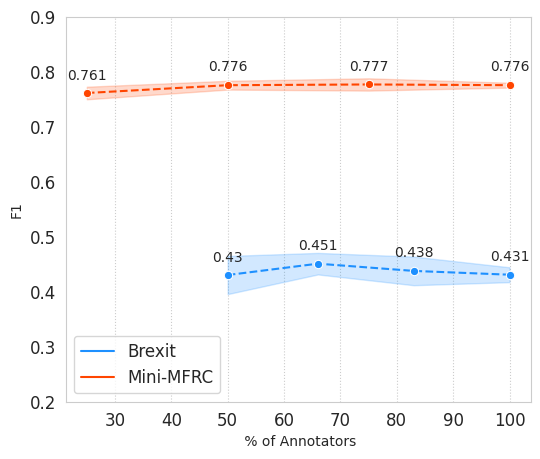

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(6, 5))
colors = {"Brexit": "dodgerblue", "Mini-MFRC": "orangered"}
ax = sns.lineplot(x="budget", y="F1",
                  hue="dataset", linestyle='--', marker='o', errorbar='sd',
                  data=all_df, markers=True, dashes=True, palette=colors)
ax.set_ylim(0.2, 0.9)

ax.xaxis.grid(True, linestyle=':', alpha=1)
ax.yaxis.grid(False)
plt.legend(loc='lower left', fontsize=12)
ax.set_xlabel(" % of Annotators")
# plt.xticks(ticks=all_df['budget'], labels=[
#            f'{int(val)}%' for val in all_df['budget']])
ax.tick_params(labelsize=12)
# Display the plot
mean_df  = all_df.groupby(['dataset', 'budget']).agg({'F1': 'mean'}).reset_index().round(3)
for i, (x, y) in enumerate(zip(mean_df['budget'], mean_df['F1'])):
    plt.annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()